In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline
import numpy as np

In [34]:
sequences = np.load("CMdata.npz")["seqs"]
structures = np.load("CMdata.npz")["strs"]

min_len = 75
max_len = 95

filtered_sequences = [s for s in sequences if min_len <= len(s) <= max_len]
filtered_structures = [v for s, v in zip(sequences,structures) if min_len <= len(s) <= max_len]
sequences = [s + "." for s in filtered_sequences]
structures = [s + "." for s in filtered_structures]

nmr = 92
print(len(structures[nmr]), len(structures[nmr]))

80 80


In [35]:
sequences[1]
structures[0]

'HHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCCCHHHHHHHHHHHHHHHHHCCCCHHHHHHHHHHHHHHHHHHHH.'

In [42]:
# build the vocabulary of characters and mappings to/from integers
chars = [
    s + v
    for seq, strc in zip(sequences, structures)
    for s, v in zip(seq , strc)
]

chars = sorted(set(chars))

stoi = {s:i for i,s in enumerate(chars)}
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{0: '..', 1: 'AC', 2: 'AE', 3: 'AH', 4: 'CC', 5: 'CH', 6: 'DC', 7: 'DH', 8: 'EC', 9: 'EE', 10: 'EH', 11: 'FC', 12: 'FE', 13: 'FH', 14: 'GC', 15: 'GE', 16: 'GH', 17: 'HC', 18: 'HH', 19: 'IC', 20: 'IE', 21: 'IH', 22: 'KC', 23: 'KE', 24: 'KH', 25: 'LC', 26: 'LE', 27: 'LH', 28: 'MC', 29: 'MH', 30: 'NC', 31: 'NH', 32: 'PC', 33: 'PE', 34: 'PH', 35: 'QC', 36: 'QE', 37: 'QH', 38: 'RC', 39: 'RE', 40: 'RH', 41: 'SC', 42: 'SE', 43: 'SH', 44: 'TC', 45: 'TE', 46: 'TH', 47: 'VC', 48: 'VE', 49: 'VH', 50: 'WC', 51: 'WH', 52: 'YC', 53: 'YH'}
54


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [56]:
# build the dataset
block_size = 70 # context length: how many characters do we take to predict the next one?

def build_dataset(sequences, structures):
  X, Y = [], []

  for seq, strc in zip(sequences, structures):
    context = [0] * block_size
    tokens = [s + v for s, v in zip(seq, strc)]  # add end token
    
    for tok in tokens:
        ix = stoi[tok]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]  # crop and append
        #print(context)

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
combined = list(zip(sequences, structures))
random.shuffle(combined)
sequences, structures = zip(*combined)
sequences = list(sequences)
structures = list(structures)
#n1 = int(0.8*len(sequences))
n2 = int(0.9*len(sequences))

Xtr,  Ytr  = build_dataset(sequences[:n2], structures[:n2])    # 90%
Xdev, Ydev = build_dataset(sequences[n2:], structures[n2:])   # 10%


Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xdev = Xdev.to(device)
Ydev = Ydev.to(device)


torch.Size([634200, 70]) torch.Size([634200])
torch.Size([70531, 70]) torch.Size([70531])


In [101]:
n_embd = 13 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
g = torch.Generator(device=device).manual_seed(1) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g, device=device)

layers = [
  nn.Linear(n_embd * block_size, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(           n_hidden, vocab_size, bias=False), nn.BatchNorm1d(vocab_size),
]

for layer in layers:
  layer.to(device)

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, nn.Linear):
      layer.weight *= 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

import torch.optim as optim

optimizer = optim.Adam(parameters, lr=1e-4)  # Initial LR
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=150000, gamma=0.1)

234410


In [96]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
    }[split]

    emb = C[x]  # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)  # (N, block_size * n_embd)

    for layer in layers:
        x = layer(x)  # (N, vocab_size), assuming final layer maps to vocab_size

    # Manual cross-entropy implementation
    # x: (N, vocab_size), y: (N,)
    log_probs = torch.log_softmax(x, dim=1)  # (N, vocab_size)
    nll = -log_probs[torch.arange(y.size(0)), y]  # Negative log-likelihood for correct class

    
    loss = nll.mean()  # Scalar

    print(split, loss.item())


split_loss('train')
split_loss('val')

#we expect around 3, if the initialization is good the probability given to the good token is 1/20 that is e-3

train 0.8467831611633301
val 1.2199639081954956


In [104]:
first_letter_map = {i: token[0] for i, token in itos.items()}

# 2. Create group indices for each unique first letter
unique_letters = sorted(set(first_letter_map.values()))
letter_to_group = {ch: i for i, ch in enumerate(unique_letters)}

# 3. For each token index, find the group index based on its first letter
token_to_group = torch.tensor([letter_to_group[first_letter_map[i]] for i in range(len(itos))])  # (54,)
n_groups = len(unique_letters)  # typically 20 (for 20 amino acids)

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
    }[split]

    emb = C[x]  # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)  # (N, block_size * n_embd)

    for layer in layers:
        x = layer(x)  # (N, 54) — raw logits over 54 tokens

    # Step 1: Compute softmax over original logits
    probs = torch.softmax(x, dim=1)  # (N, 54)

    # Step 2: Sum probabilities by first-letter groups
    grouped_probs = torch.zeros(x.size(0), n_groups, device=x.device)  # (N, n_groups)
    grouped_probs.index_add_(1, token_to_group.to(x.device), probs)  # add probs by group

    # Step 3: Map target token to its group (based on first letter)
    target_group = token_to_group[y]  # (N,)

    # Step 4: Compute log and negative log-likelihood
    log_grouped_probs = torch.log(grouped_probs + 1e-9)  # avoid log(0)
    nll = -log_grouped_probs[torch.arange(y.size(0)), target_group]
    loss = nll.mean()

    print(split, loss.item())


split_loss('train')
split_loss('val')

train 0.8031206727027893
val 1.1395087242126465


In [77]:
n_groups

21

In [102]:
g = torch.Generator(device=device).manual_seed(1) # for reproducibility
max_steps = 90001
batch_size = 256
lossi = []
ud = []

lri = (torch.logspace(-4,0,max_steps))


for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device = device)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  #optimizer.zero_grad()

  for p in parameters:
    p.grad = None
  loss.backward()


  # update
  #optimizer.step()
  #scheduler.step()

  lr = 0.01 if i < 60000 else 0.001 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print('epoch    ',f'{i}')
    split_loss('val')
    split_loss('train')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  #if i >= 10000:
   # break # AFTER_DEBUG: would take out obviously to run full optimization
  

# --- Saving ---

param_dict = {}
param_dict['C'] = C.detach().cpu().numpy()
for i, layer in enumerate(layers):
    for name, param in layer.named_parameters():
        param_dict[f'layer_{i}_{name}'] = param.detach().cpu().numpy()
np.savez(f'nn_parameters_{batch_size}.npz', **param_dict)


epoch     0
val 3.998544454574585
train 3.998453140258789
epoch     10000
val 1.426277756690979
train 1.3052442073822021
epoch     20000
val 1.2878681421279907
train 1.1153476238250732
epoch     30000
val 1.2572486400604248
train 1.039232850074768
epoch     40000
val 1.2331438064575195
train 0.9806510210037231
epoch     50000
val 1.2220027446746826
train 0.938591718673706
epoch     60000
val 1.2219825983047485
train 0.9069902896881104
epoch     70000
val 1.1950445175170898
train 0.8472083210945129
epoch     80000
val 1.1985946893692017
train 0.838125467300415
epoch     90000
val 1.2021366357803345
train 0.8322769999504089


In [60]:
# --- Loading ---
with torch.no_grad():

    loaded = np.load('nn_parameters_256_ss.npz')
    C.copy_(torch.tensor(loaded['C'], device=C.device))
    for i, layer in enumerate(layers):
        for name, param in layer.named_parameters():
            param.copy_(torch.tensor(loaded[f'layer_{i}_{name}'], device=param.device))

In [103]:
split_loss('train')
split_loss('val')

train 0.8322769999504089
val 1.2021366357803345


layer 2 (      Tanh): mean +0.01, std 0.70, saturated: 11.36%
layer 5 (      Tanh): mean +0.00, std 0.70, saturated: 10.28%


Text(0.5, 1.0, 'activation distribution')

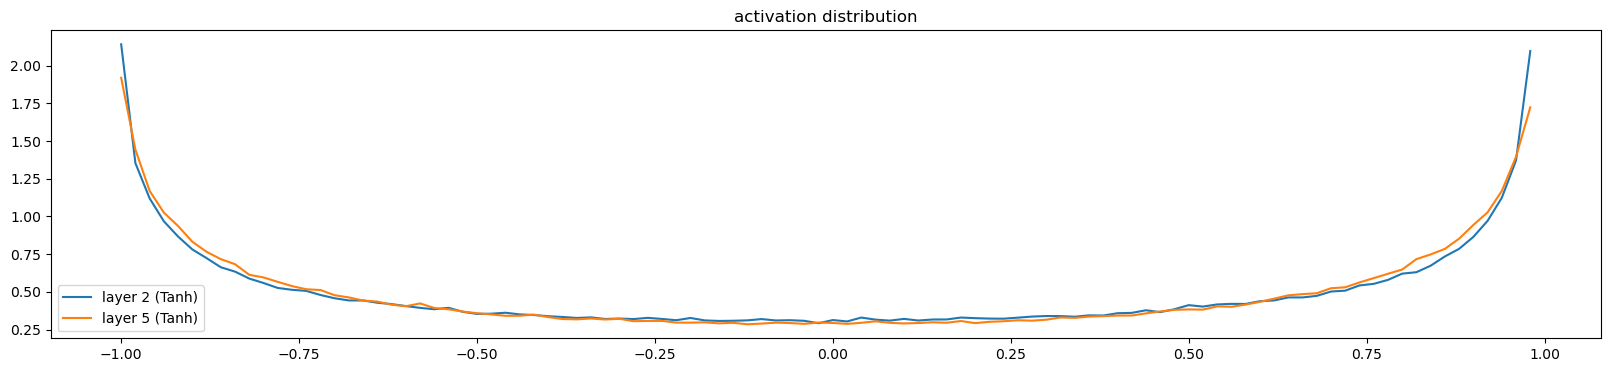

In [62]:
# visualize histograms

emb = C[Xdev] # embed the characters into vectors
x = emb.view(emb.shape[0], -1)


activations = []

for i, layer in enumerate(layers):
    x = layer(x)
    if isinstance(layer, nn.Tanh):  # or nn.ReLU, nn.LeakyReLU, etc.
        activations.append((i, layer.__class__.__name__, x.detach().cpu().view(-1)))

# Plotting
plt.figure(figsize=(20, 4))
legends = []

for i, name, t in activations:
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' %
          (i, name, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, bins=100, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({name})')

plt.legend(legends)
plt.title('activation distribution')


layer 2 (      Tanh): grad mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): grad mean -0.00, std 0.00, saturated: 0.00%


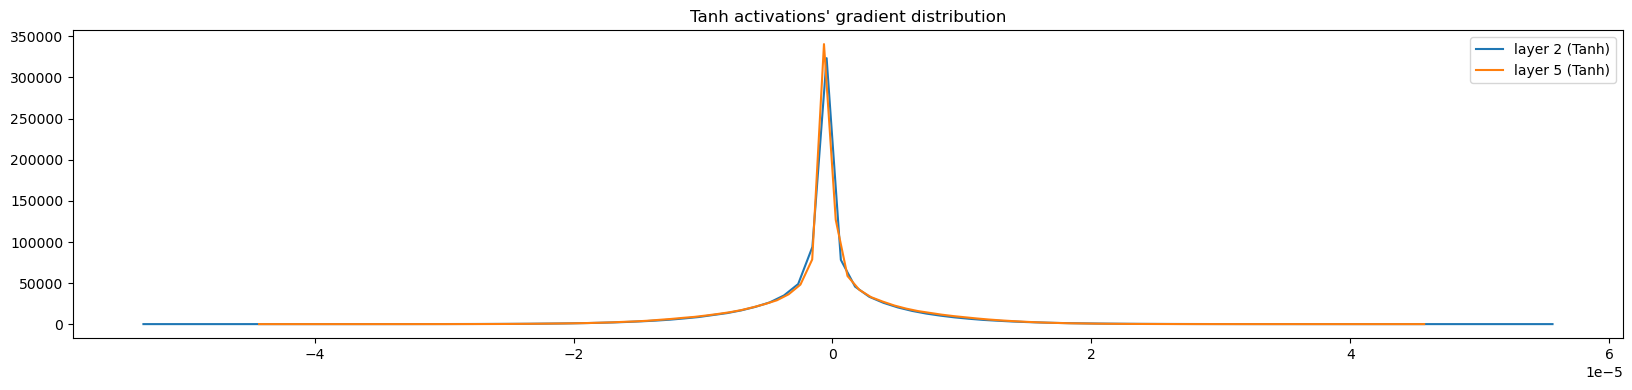

In [52]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Example dummy input
emb = C[Xdev]  # Embedding step
x = emb.view(emb.shape[0], -1)  # Flatten

activations = []

# Forward pass and retain gradients for Tanh outputs
for i, layer in enumerate(layers):
    x = layer(x)
    if isinstance(layer, nn.Tanh):
        x.retain_grad()  # <-- retain gradient for this activation
        activations.append((i, layer.__class__.__name__, x))

# Compute loss and backward
logits = x  # Assume last x is model output
loss = F.cross_entropy(logits, Ydev)  # Assume Ydev is your target
loss.backward()

# Plotting gradients of Tanh activations
plt.figure(figsize=(20, 4))
legends = []

for i, name, act in activations:
    g = act.grad  # now it should exist
    if g is None:
        continue
    g = g.detach().cpu().view(-1)
    print('layer %d (%10s): grad mean %+.2f, std %.2f, saturated: %.2f%%' %
          (i, name, g.mean(), g.std(), (g.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(g, bins=100, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({name})')

plt.legend(legends)
plt.title("Tanh activations' gradient distribution")
plt.show()

weight   (54, 10) | mean +0.000000 | std 5.149838e-03 | grad:data ratio 5.054304e-03
weight (100, 700) | mean -0.000228 | std 1.027868e-02 | grad:data ratio 2.093121e-01
weight (100, 100) | mean -0.000011 | std 1.745534e-02 | grad:data ratio 1.839276e-01
weight  (54, 100) | mean +0.000028 | std 1.619152e-02 | grad:data ratio 1.705145e-01


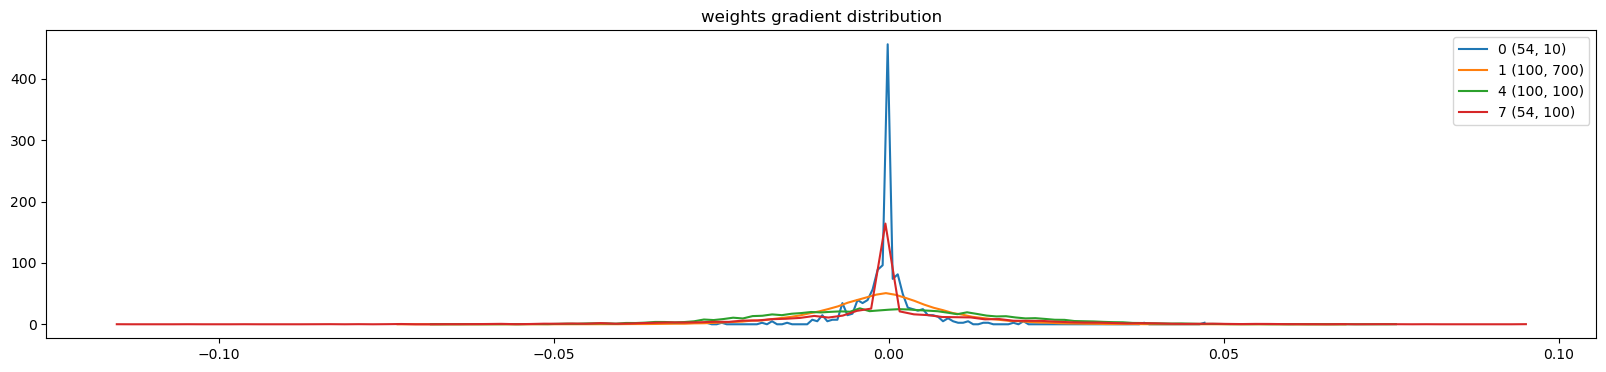

In [53]:
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(parameters):
    t = p.grad
    if t is None:
        continue  # skip if grad is None (e.g., frozen layers)

    if p.ndim == 2:
        t = t.detach().cpu().view(-1)  # flatten & move to CPU
        param_std = p.std().detach().cpu()
        grad_std = t.std()
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' %
              (tuple(p.shape), t.mean(), grad_std, grad_std / param_std))

        hy, hx = torch.histogram(t, bins=100, density=True)
        plt.plot(hx[:-1].cpu(), hy.cpu())  # ensure plotting from CPU
        legends.append(f'{i} {tuple(p.shape)}')

plt.legend(legends)
plt.title('weights gradient distribution')
plt.show()


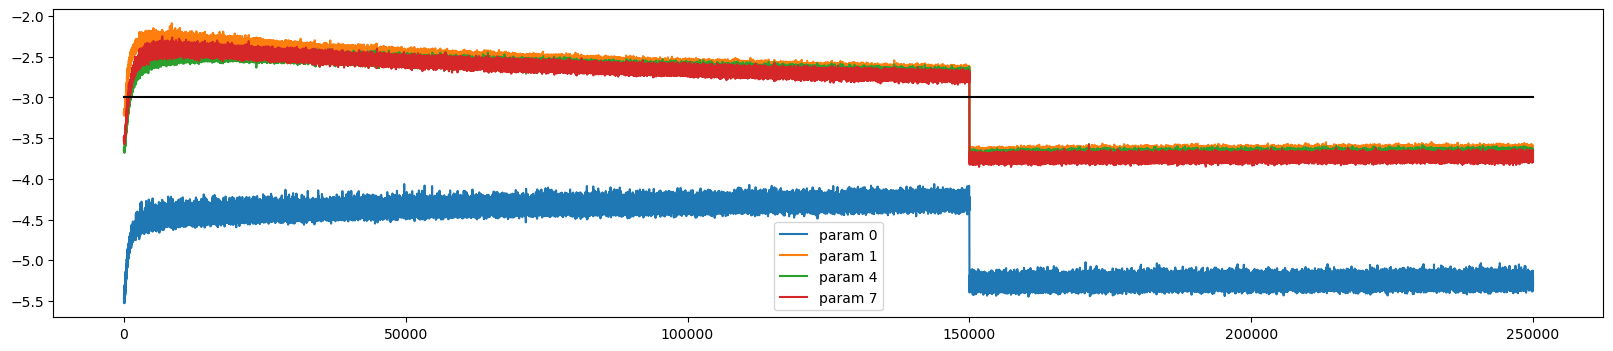

In [63]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
 if p.ndim == 2:
   plt.plot([ud[j][i] for j in range(len(ud))])
   legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [ ]:
g = torch.Generator(device=device).manual_seed(0)
n = 1000

for layer in layers:
    layer.eval()

with open('generated_sequences_ss.txt', 'w') as f:
    for _ in range(n):
        out = []
        context = [0] * block_size  # initialize with all ...
        while True:
            emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
            x = emb.view(emb.shape[0], -1)  # flatten
            for layer in layers:
                x = layer(x)
            logits = x
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:  # special token
                break

        sequence = ''.join(itos[i][0] for i in out[0:-1])
        header = f'>seq_{_}'
        #print(header)
        #print(sequence)
        f.write(header + '\n')
        f.write(sequence + '\n')